# Регрессия

In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

import numpy as np
np.random.seed(42)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import Ridge, Lasso
import lightgbm as lgb
import shap

import seaborn as sns
import matplotlib.pyplot as plt
color = "#FF0000"

BOLD = '\033[1m'
END = '\033[0m'

import warnings
warnings.filterwarnings('ignore')

c:\Users\tranm\anaconda3\envs\py311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 Сбор и первичный анализ данных

### 1.1 Сбор данных

In [2]:
df_views = pd.read_csv('views.csv')
df_views

,Date,Video Title,External Video ID,Video Length,Thumbnail link,Views,Video Likes Added,Video Dislikes Added,Video Likes Removed,User Subscriptions Added,User Subscriptions Removed,Average View Percentage,Average Watch Time,User Comments Added
0,19 Jan 2022,Kaggle Project From Scratch - Part 2 (Exploratory Data Analysis),KQ80oD_boBM,2191,https://i.ytimg.com/vi/KQ80oD_boBM/hqdefault.jpg,13,0,0,0,0,0,0.069055,151.300154,0
1,19 Jan 2022,Welcome To My Channel | Ken Jee | Data Science,smeFkHwnM_k,51,https://i.ytimg.com/vi/smeFkHwnM_k/hqdefault.jpg,2,0,0,0,1,0,0.471255,24.034000,0
2,19 Jan 2022,How She Dominated the FAANG Data Science Interview (@Tina Huang ) - KNN EP. 11,vfV4nm004VQ,2686,https://i.ytimg.com/vi/vfV4nm004VQ/hqdefault.jpg,10,0,0,0,0,0,0.126049,338.567500,0
3,19 Jan 2022,The 9 Books That Changed My Perspective in 2019,3TrAYmrmA8o,980,https://i.ytimg.com/vi/3TrAYmrmA8o/hqdefault.jpg,1,0,0,0,0,0,0.011508,11.278000,0
4,19 Jan 2022,Interview with the Director of AI Research @ NVIDIA (Anima Anandkumar) - KNN EP. 07,Xgg7dIKys9E,2904,https://i.ytimg.com/vi/Xgg7dIKys9E/hqdefault.jpg,1,0,0,0,0,0,0.007541,21.900000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111852,21 Nov 2017,Predicting Crypto-Currency Price Using RNN lSTM & GRU,qfRhKHV8-t4,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,2,0,0,0,0,0,0.693108,215.556500,0
111853,20 Nov 2017,Predicting Crypto-Currency Price Using RNN lSTM & GRU,qfRhKHV8-t4,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,9,0,0,0,0,0,0.492501,153.167667,0
111854,19 Nov 2017,Predicting Crypto-Currency Price Using RNN lSTM & GRU,qfRhKHV8-t4,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,4,0,0,0,0,0,0.087268,27.140250,0
111855,18 Nov 2017,Predicting Crypto-Currency Price Using RNN lSTM & GRU,qfRhKHV8-t4,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,13,0,0,0,0,0,0.444176,138.138769,0


In [3]:
print(f"\nРазмерность (количество наблюдений, количество признаков): {df_views.shape}")
print(f"\nТипы данных:\n{df_views.dtypes}")

missing = df_views.isnull().sum()
missing_percent = (missing / len(df_views)) * 100
missing_df = pd.DataFrame({'Количество пропусков': missing, 'Доля (%)': missing_percent})
missing_df = missing_df[missing_df['Количество пропусков'] > 0].sort_values('Доля (%)', ascending=False)

if not missing_df.empty:
    print(f"\nПропуски в данных:\n{missing_df}")
else:
    print("\nПропуски в данных отсутствуют.")


Размерность (количество наблюдений, количество признаков): (111857, 14)

Типы данных:
Date                              str
Video Title                       str
External Video ID                 str
Video Length                    int64
Thumbnail link                    str
Views                           int64
Video Likes Added               int64
Video Dislikes Added            int64
Video Likes Removed             int64
User Subscriptions Added        int64
User Subscriptions Removed      int64
Average View Percentage       float64
Average Watch Time            float64
User Comments Added             int64
dtype: object

Пропуски в данных:
                         Количество пропусков  Доля (%)
Average View Percentage                  1347  1.204216
Average Watch Time                       1347  1.204216


In [4]:
df_videos = pd.read_csv('views_videos.csv')
df_videos.drop(0, inplace=True)

df_views['Video Publish Date'] = df_views['External Video ID'].map(df_videos.set_index('Video')['Video pub­lish time'])
df_views['Video Publish Date'] = pd.to_datetime(df_views['Video Publish Date'])
df_views['Date'] = pd.to_datetime(df_views['Date'], format='mixed')

df_views

,Date,Video Title,External Video ID,Video Length,Thumbnail link,Views,Video Likes Added,Video Dislikes Added,Video Likes Removed,User Subscriptions Added,User Subscriptions Removed,Average View Percentage,Average Watch Time,User Comments Added,Video Publish Date
0,2022-01-19,Kaggle Project From Scratch - Part 2 (Exploratory Data Analysis),KQ80oD_boBM,2191,https://i.ytimg.com/vi/KQ80oD_boBM/hqdefault.jpg,13,0,0,0,0,0,0.069055,151.300154,0,2021-01-08
1,2022-01-19,Welcome To My Channel | Ken Jee | Data Science,smeFkHwnM_k,51,https://i.ytimg.com/vi/smeFkHwnM_k/hqdefault.jpg,2,0,0,0,1,0,0.471255,24.034000,0,2019-03-03
2,2022-01-19,How She Dominated the FAANG Data Science Interview (@Tina Huang ) - KNN EP. 11,vfV4nm004VQ,2686,https://i.ytimg.com/vi/vfV4nm004VQ/hqdefault.jpg,10,0,0,0,0,0,0.126049,338.567500,0,2020-09-02
3,2022-01-19,The 9 Books That Changed My Perspective in 2019,3TrAYmrmA8o,980,https://i.ytimg.com/vi/3TrAYmrmA8o/hqdefault.jpg,1,0,0,0,0,0,0.011508,11.278000,0,2020-01-03
4,2022-01-19,Interview with the Director of AI Research @ NVIDIA (Anima Anandkumar) - KNN EP. 07,Xgg7dIKys9E,2904,https://i.ytimg.com/vi/Xgg7dIKys9E/hqdefault.jpg,1,0,0,0,0,0,0.007541,21.900000,0,2020-08-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111852,2017-11-21,Predicting Crypto-Currency Price Using RNN lSTM & GRU,qfRhKHV8-t4,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,2,0,0,0,0,0,0.693108,215.556500,0,2017-11-18
111853,2017-11-20,Predicting Crypto-Currency Price Using RNN lSTM & GRU,qfRhKHV8-t4,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,9,0,0,0,0,0,0.492501,153.167667,0,2017-11-18
111854,2017-11-19,Predicting Crypto-Currency Price Using RNN lSTM & GRU,qfRhKHV8-t4,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,4,0,0,0,0,0,0.087268,27.140250,0,2017-11-18
111855,2017-11-18,Predicting Crypto-Currency Price Using RNN lSTM & GRU,qfRhKHV8-t4,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,13,0,0,0,0,0,0.444176,138.138769,0,2017-11-18


In [5]:
df = df_views.copy()
df['Video Age (Days)'] = (df['Date'] - df['Video Publish Date']).dt.days

def add_lags(df_group):
    df_group = df_group.sort_values('Video Age (Days)')

    min_age = df_group['Video Age (Days)'].min()
    max_age = df_group['Video Age (Days)'].max()
    
    complete_ages = pd.DataFrame({'Video Age (Days)': range(min_age, max_age + 1)})
    
    complete = df_group.merge(complete_ages, on='Video Age (Days)')
    complete = complete.sort_values('Video Age (Days)')
    
    complete['Views_filled'] = complete['Views'].ffill()
    
    complete['Views_Lag1'] = complete['Views_filled'].shift(1)
    
    result = complete[complete['Views'].notna()].copy()
    return result.drop(columns=['Views_filled']).sort_values('Video Age (Days)')

df = df.groupby('External Video ID').apply(add_lags).reset_index(drop=True)
df = df.sort_values(by=['Date', 'Video Age (Days)'])

df['Day Name'] = df['Date'].dt.day_name()

df

,Date,Video Title,Video Length,Thumbnail link,Views,Video Likes Added,Video Dislikes Added,Video Likes Removed,User Subscriptions Added,User Subscriptions Removed,Average View Percentage,Average Watch Time,User Comments Added,Video Publish Date,Video Age (Days),Views_Lag1,Day Name
15887,2017-11-01,ProjectDemoCSC478_UFCFightData,729,https://i.ytimg.com/vi/5p73cIRYCZg/hqdefault.jpg,1,0,0,0,0,0,0.003018,2.200000,0,2017-06-06,148,NaN,Wednesday
95811,2017-11-18,Predicting Crypto-Currency Price Using RNN lSTM & GRU,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,13,0,0,0,0,0,0.444176,138.138769,0,2017-11-18,0,NaN,Saturday
95812,2017-11-19,Predicting Crypto-Currency Price Using RNN lSTM & GRU,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,4,0,0,0,0,0,0.087268,27.140250,0,2017-11-18,1,13.0,Sunday
95813,2017-11-20,Predicting Crypto-Currency Price Using RNN lSTM & GRU,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,9,0,0,0,0,0,0.492501,153.167667,0,2017-11-18,2,4.0,Monday
95814,2017-11-21,Predicting Crypto-Currency Price Using RNN lSTM & GRU,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,2,0,0,0,0,0,0.693108,215.556500,0,2017-11-18,3,9.0,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82282,2022-01-19,How to Simulate NBA Games in Python,556,https://i.ytimg.com/vi/irjTWNV0eAY/hqdefault.jpg,6,1,0,0,0,0,0.422689,235.015000,0,2018-11-19,1157,10.0,Wednesday
48980,2022-01-19,Should You Get A Masters in Data Science?,337,https://i.ytimg.com/vi/RRSRKf9eQxc/hqdefault.jpg,17,0,0,0,0,0,0.450564,151.840000,0,2018-11-14,1162,10.0,Wednesday
37183,2022-01-19,How I Became A Data Scientist From a Business Background,619,https://i.ytimg.com/vi/IFceyuL6GZY/hqdefault.jpg,1,0,0,0,0,0,0.038934,24.100000,0,2018-11-12,1164,3.0,Wednesday
63421,2022-01-19,Predicting Season Long NBA Wins Using Multiple Linear Regression,539,https://i.ytimg.com/vi/Y_SMU701qlA/hqdefault.jpg,4,0,0,0,0,0,0.305997,164.932500,0,2018-07-10,1289,5.0,Wednesday


### 1.2 Визуализация данных

In [6]:
features_numeric = ['Views',
                    'Video Age (Days)', 'Video Length', 'Average View Percentage',
                    'Video Likes Added', 'User Subscriptions Added']

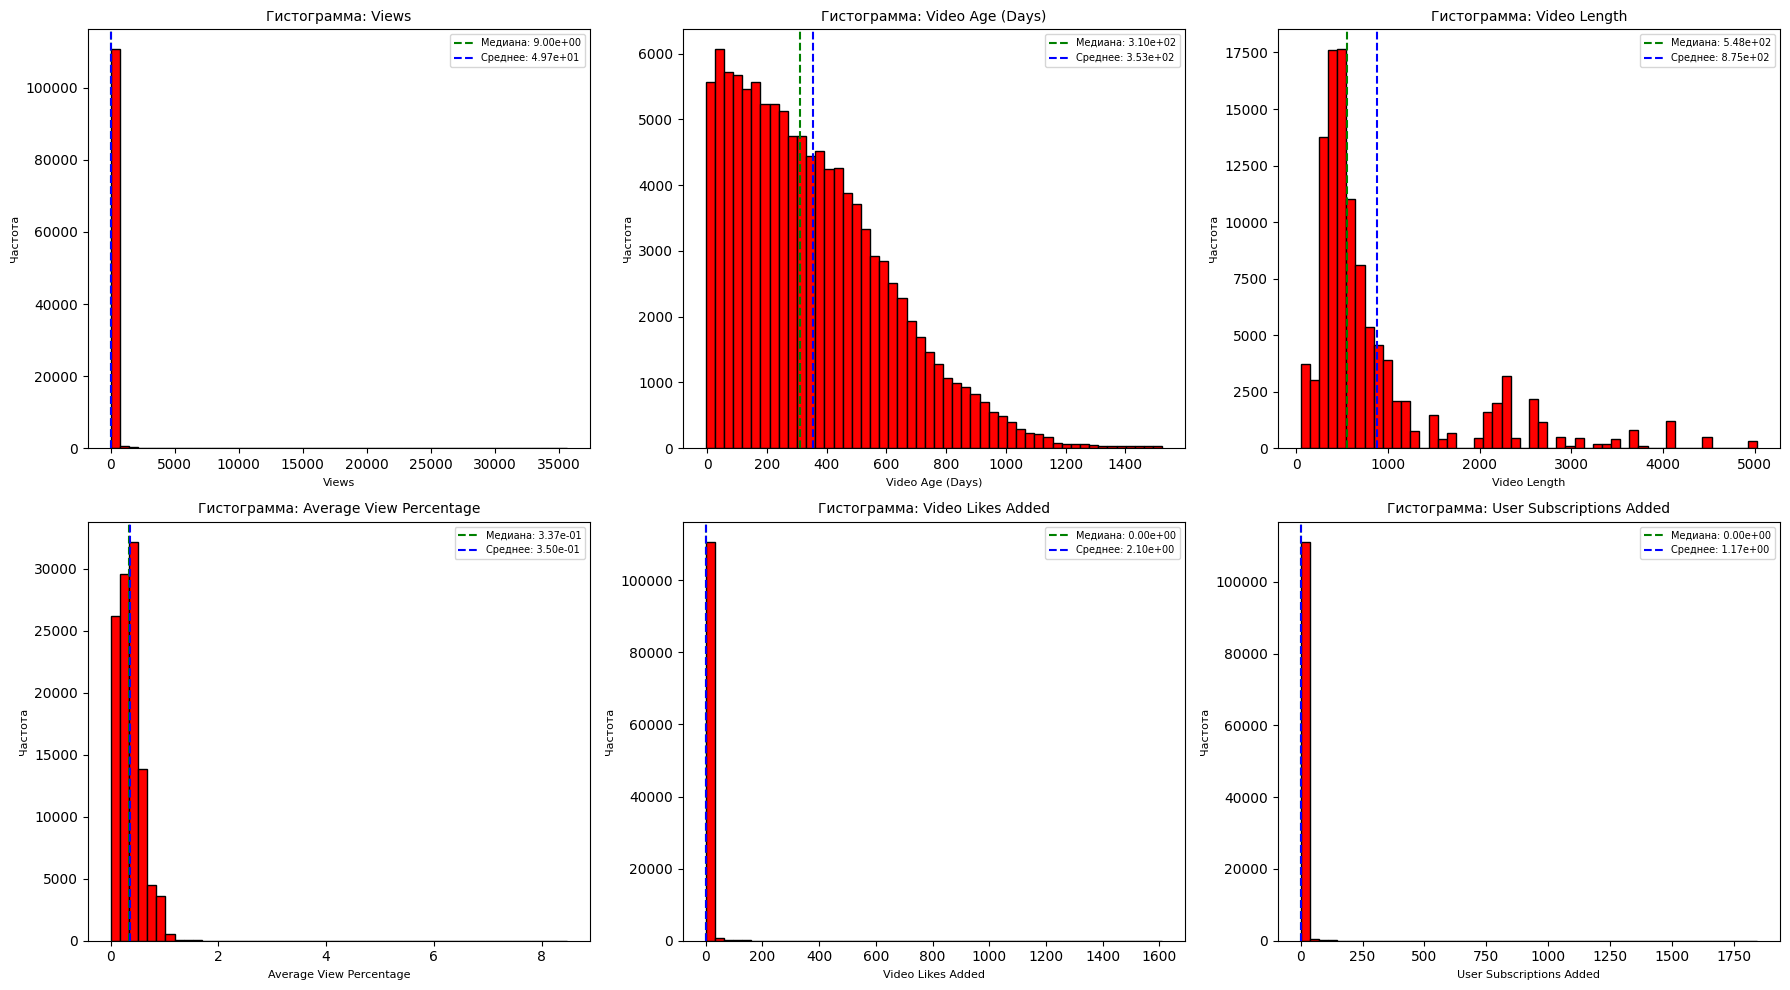

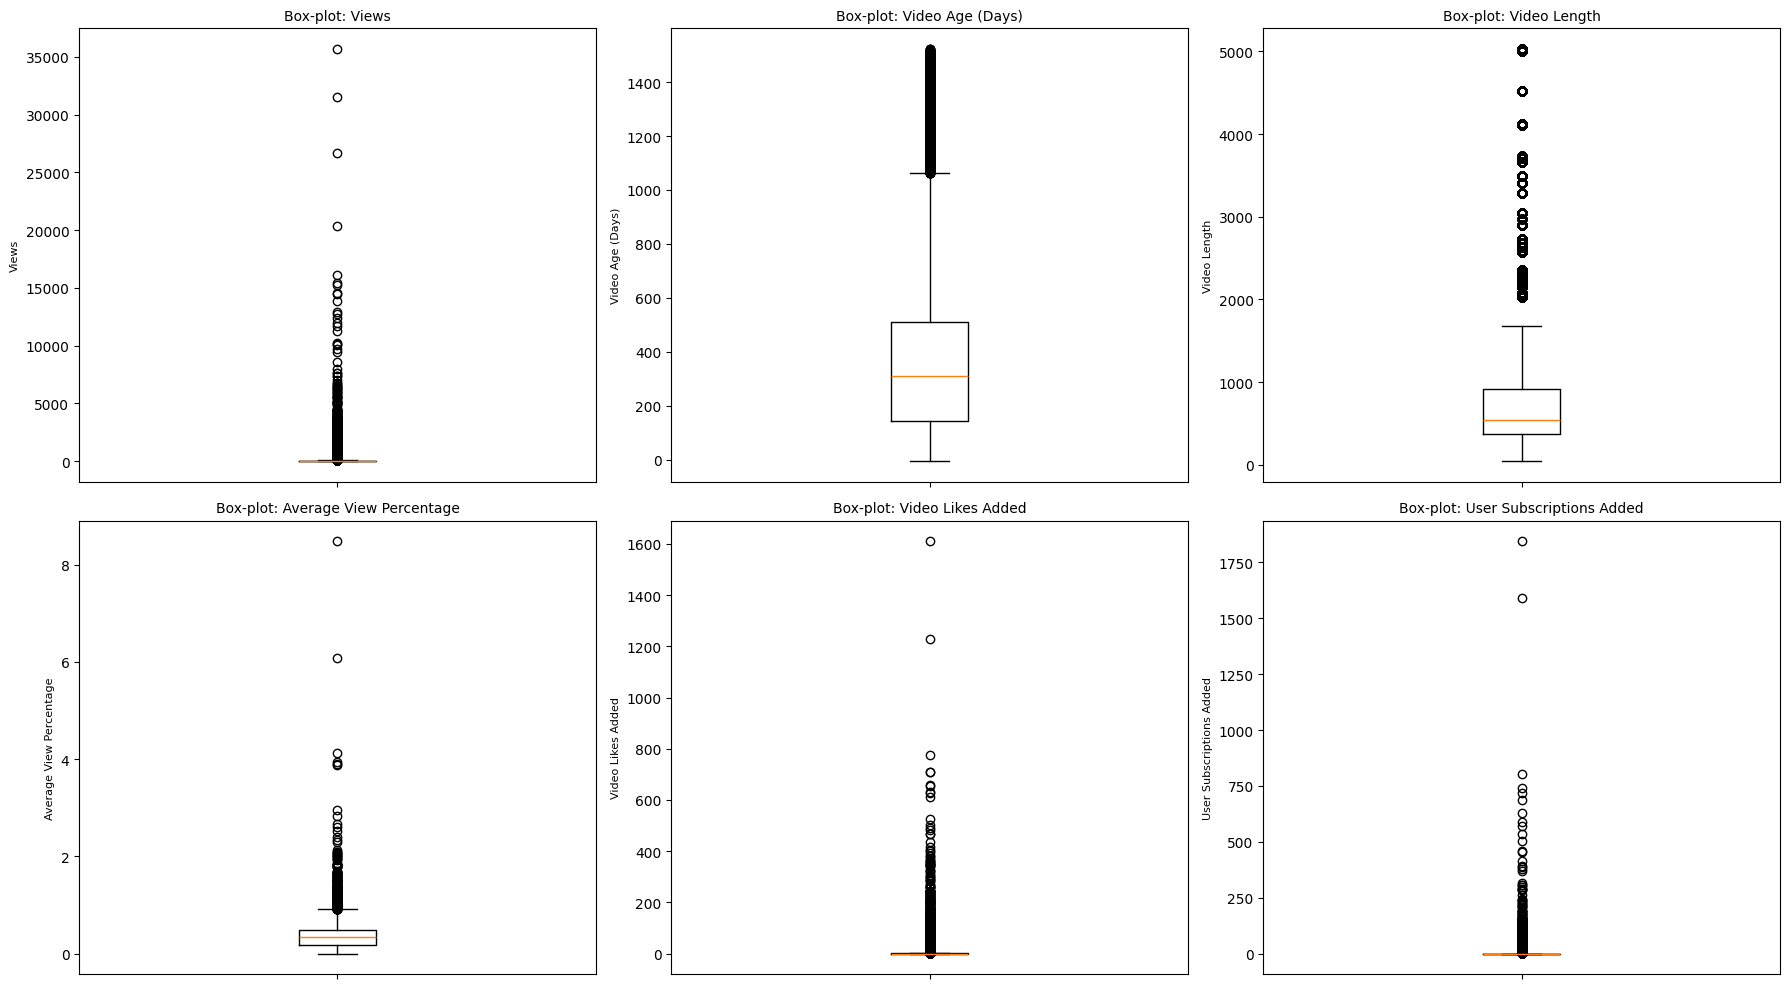

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, feature in enumerate(features_numeric):
    clean_data = df[feature].dropna()
    axes[i].hist(clean_data, bins=50, color=color, edgecolor='black')
    axes[i].set_title(f'Гистограмма: {feature}', fontsize=10)
    axes[i].set_xlabel(feature, fontsize=8)
    axes[i].set_ylabel('Частота', fontsize=8)
    axes[i].axvline(clean_data.median(), color='green', linestyle='--', 
                    label=f'Медиана: {clean_data.median():.2e}')
    axes[i].axvline(clean_data.mean(), color='blue', linestyle='--', 
                    label=f'Среднее: {clean_data.mean():.2e}')
    axes[i].legend(fontsize=7)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, feature in enumerate(features_numeric):
    clean_data = df[feature].dropna()
    axes[i].boxplot(clean_data)
    axes[i].set_title(f'Box-plot: {feature}', fontsize=10)
    axes[i].set_ylabel(feature, fontsize=8)
    axes[i].set_xticklabels([])

plt.tight_layout()
plt.show()

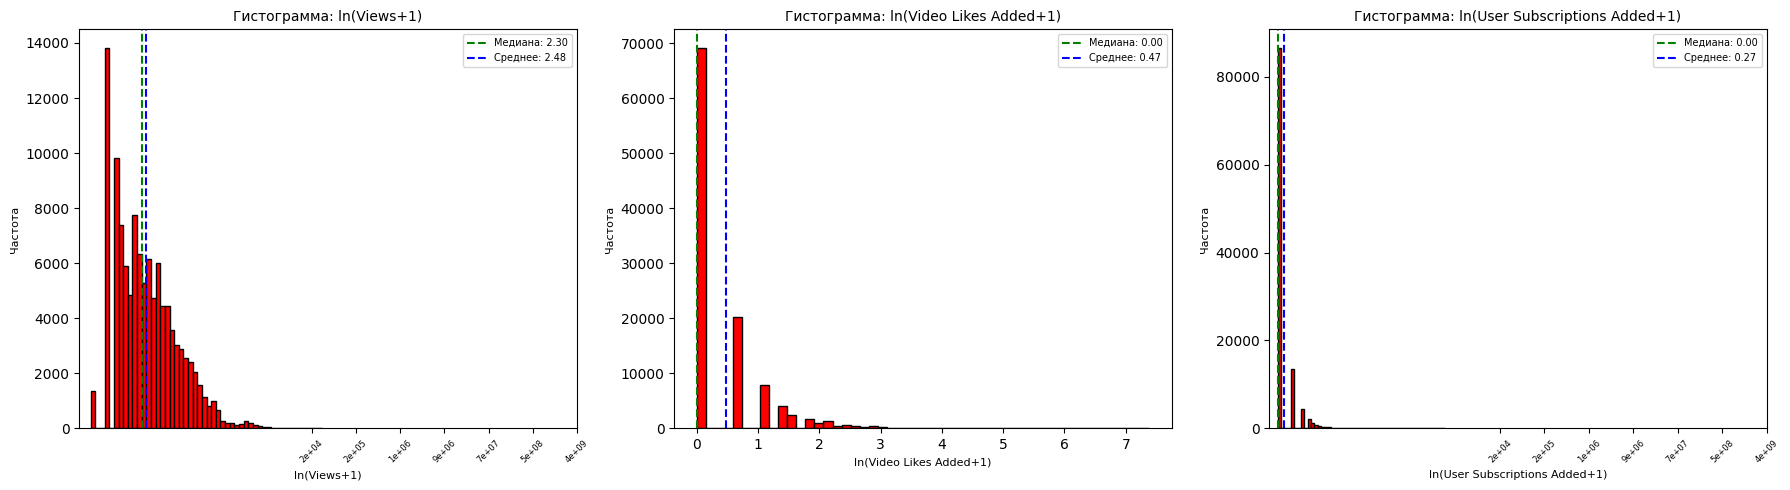

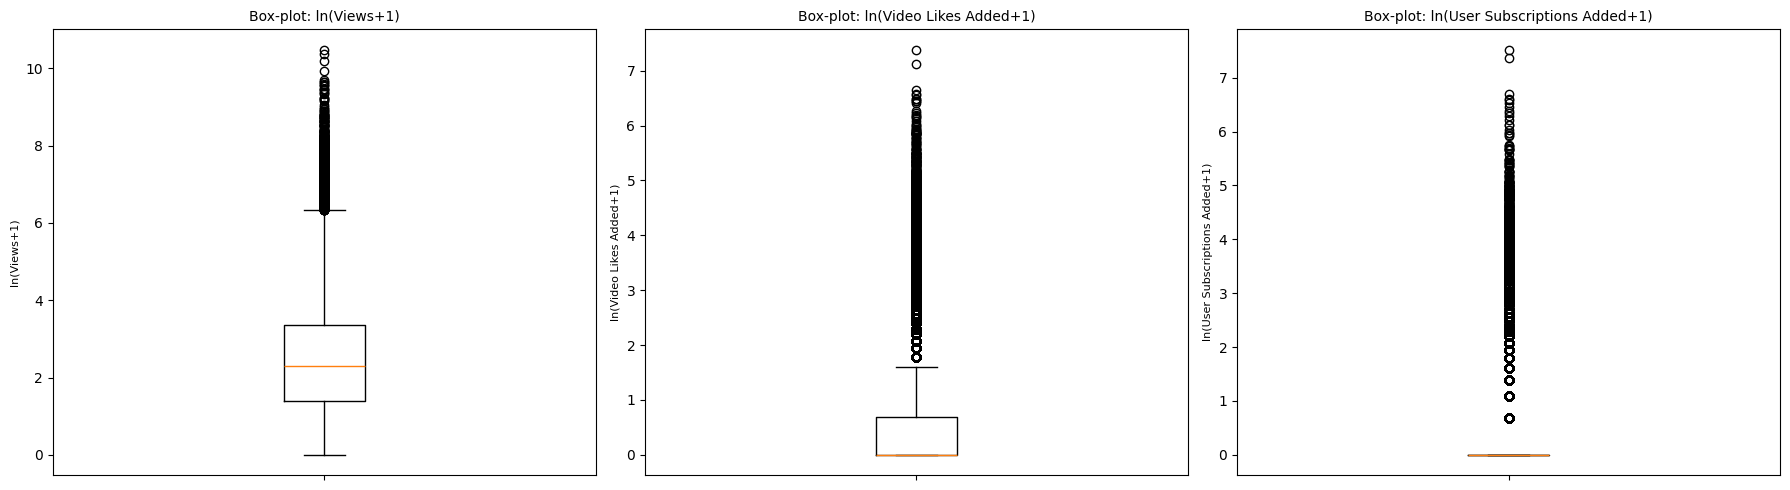

In [8]:
df_log = pd.DataFrame()
log_features = []

for feature in ['Views', 'Video Likes Added', 'User Subscriptions Added']:
    log_name = f"{feature}_log"
    df_log[log_name] = np.log1p(df[feature])
    log_features.append(log_name)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()
for i, feature in enumerate(log_features):
    clean_data = df_log[feature].dropna()
    original_name = feature.replace('_log', '')
    axes[i].hist(clean_data, bins=50, color=color, edgecolor='black')
    axes[i].set_title(f'Гистограмма: ln({original_name}+1)', fontsize=10)
    axes[i].set_xlabel(f'ln({original_name}+1)', fontsize=8)
    axes[i].set_ylabel('Частота', fontsize=8)
    
    axes[i].axvline(clean_data.median(), color='green', linestyle='--', 
                    label=f'Медиана: {clean_data.median():.2f}')
    axes[i].axvline(clean_data.mean(), color='blue', linestyle='--', 
                    label=f'Среднее: {clean_data.mean():.2f}')
    axes[i].legend(fontsize=7)
    # Добавляем метки исходных значений для интерпретации (для логарифмированных признаков)
    if 'Subscriptions' in feature or 'Views' in feature:
        log_ticks = [10, 12, 14, 16, 18, 20, 22]
        axes[i].set_xticks(log_ticks)
        labels = [f'{np.exp(tick):.0e}' for tick in log_ticks]
        axes[i].set_xticklabels(labels, rotation=45, fontsize=6)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()
for i, feature in enumerate(log_features):
    clean_data = df_log[feature].dropna()
    original_name = feature.replace('_log', '')
    axes[i].boxplot(clean_data)
    if feature != 'age_days':
        axes[i].set_title(f'Box-plot: ln({original_name}+1)', fontsize=10)
        axes[i].set_ylabel(f'ln({original_name}+1)', fontsize=8)
    else:
        axes[i].set_title(f'Box-plot: {feature}', fontsize=10)
        axes[i].set_ylabel(feature, fontsize=8)
    axes[i].set_xticklabels([])
plt.tight_layout()
plt.show()

In [15]:
def stats(df, features):
    results = []
    
    for feature in features:
        data = df[feature].dropna()
        
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        outlier_count = len(outliers)
        outlier_percent = (outlier_count / len(data)) * 100
        
        results.append({
            'Признак': feature,
            'Математическое ожидание (среднее)': data.mean(),
            'Дисперсия': data.var(),
            'Минимум': data.min(),
            'Q1 (25% квартиль)': Q1,
            'Q2 (Медиана)': data.quantile(0.5),
            'Q3 (75% квартиль)': Q3,
            'Максимум': data.max(),
            'IQR': IQR,
            'Нижняя граница': round(lower_bound, 2),
            'Верхняя граница': round(upper_bound, 2),
            'Количество выбросов': outlier_count,
            'Доля выбросов (%)': round(outlier_percent, 2)
        })
    
    results_df = pd.DataFrame(results).set_index('Признак')
    return results_df

views_stats = stats(df, features_numeric)
views_stats.T

Признак,Views,Video Age (Days),Video Length,Average View Percentage,Video Likes Added,User Subscriptions Added
Математическое ожидание (среднее),49.714287,352.847198,874.615876,0.350456,2.095533,1.169180
Дисперсия,100208.660098,65733.163767,741833.671009,0.054087,203.452985,146.629456
Минимум,0.000000,-5.000000,47.000000,0.000000,0.000000,0.000000
Q1 (25% квартиль),3.000000,145.000000,375.000000,0.178010,0.000000,0.000000
Q2 (Медиана),9.000000,310.000000,548.000000,0.336824,0.000000,0.000000
Q3 (75% квартиль),28.000000,512.000000,917.000000,0.476257,1.000000,0.000000
Максимум,35677.000000,1523.000000,5029.000000,8.476340,1610.000000,1844.000000
IQR,25.000000,367.000000,542.000000,0.298246,1.000000,0.000000
Нижняя граница,-34.500000,-405.500000,-438.000000,-0.270000,-1.500000,0.000000
Верхняя граница,65.500000,1062.500000,1730.000000,0.920000,2.500000,0.000000


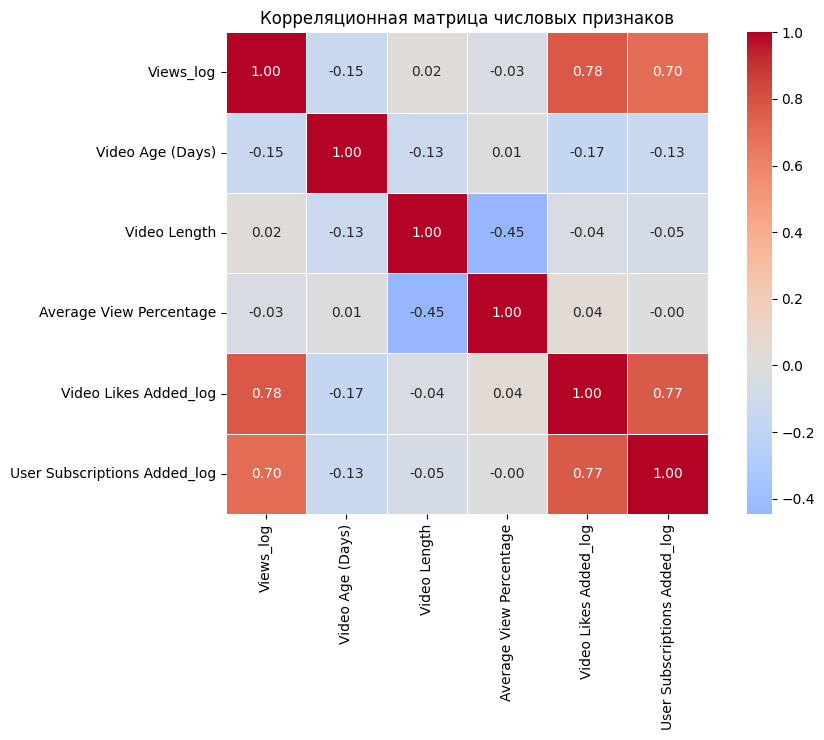

In [17]:
df_corr = pd.DataFrame()
corr_features = ['Views_log', 
                 'Video Age (Days)', 'Video Length', 'Average View Percentage',
                 'Video Likes Added_log', 'User Subscriptions Added_log']
for feature in corr_features:
    if feature in log_features:
        df_corr[feature] = df_log[feature]
    else:
        df_corr[feature] = df[feature]

corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 7.5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()

### 1.3. Предобработка данных

In [11]:
for feature in ['Average View Percentage', 'Average Watch Time', 'Views_Lag1']:
    df[feature] = df[feature].fillna(0, inplace=True)
    print(f"{feature}: заполнено 0")

df.isnull().sum()

Average View Percentage: заполнено 0
Average Watch Time: заполнено 0
Views_Lag1: заполнено 0


Date                          0
Video Title                   0
Video Length                  0
Thumbnail link                0
Views                         0
Video Likes Added             0
Video Dislikes Added          0
Video Likes Removed           0
User Subscriptions Added      0
User Subscriptions Removed    0
Average View Percentage       0
Average Watch Time            0
User Comments Added           0
Video Publish Date            0
Video Age (Days)              0
Views_Lag1                    0
Day Name                      0
dtype: int64

In [12]:
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Day Name'] = pd.Categorical(df['Day Name'], categories=day_names, ordered=True)

df = pd.get_dummies(df, columns=['Day Name'], drop_first=True, 
                    prefix='', prefix_sep='', 
                    dtype=int)

# print(f"{feature}: закодировано {len(le.classes_)} уникальных категорий")

df

,Date,Video Title,Video Length,Thumbnail link,Views,Video Likes Added,Video Dislikes Added,Video Likes Removed,User Subscriptions Added,User Subscriptions Removed,Average View Percentage,Average Watch Time,User Comments Added,Video Publish Date,Video Age (Days),Views_Lag1,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
15887,2017-11-01,ProjectDemoCSC478_UFCFightData,729,https://i.ytimg.com/vi/5p73cIRYCZg/hqdefault.jpg,1,0,0,0,0,0,0.003018,2.200000,0,2017-06-06,148,0.0,0,1,0,0,0,0
95811,2017-11-18,Predicting Crypto-Currency Price Using RNN lSTM & GRU,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,13,0,0,0,0,0,0.444176,138.138769,0,2017-11-18,0,0.0,0,0,0,0,1,0
95812,2017-11-19,Predicting Crypto-Currency Price Using RNN lSTM & GRU,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,4,0,0,0,0,0,0.087268,27.140250,0,2017-11-18,1,13.0,0,0,0,0,0,1
95813,2017-11-20,Predicting Crypto-Currency Price Using RNN lSTM & GRU,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,9,0,0,0,0,0,0.492501,153.167667,0,2017-11-18,2,4.0,0,0,0,0,0,0
95814,2017-11-21,Predicting Crypto-Currency Price Using RNN lSTM & GRU,311,https://i.ytimg.com/vi/qfRhKHV8-t4/hqdefault.jpg,2,0,0,0,0,0,0.693108,215.556500,0,2017-11-18,3,9.0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82282,2022-01-19,How to Simulate NBA Games in Python,556,https://i.ytimg.com/vi/irjTWNV0eAY/hqdefault.jpg,6,1,0,0,0,0,0.422689,235.015000,0,2018-11-19,1157,10.0,0,1,0,0,0,0
48980,2022-01-19,Should You Get A Masters in Data Science?,337,https://i.ytimg.com/vi/RRSRKf9eQxc/hqdefault.jpg,17,0,0,0,0,0,0.450564,151.840000,0,2018-11-14,1162,10.0,0,1,0,0,0,0
37183,2022-01-19,How I Became A Data Scientist From a Business Background,619,https://i.ytimg.com/vi/IFceyuL6GZY/hqdefault.jpg,1,0,0,0,0,0,0.038934,24.100000,0,2018-11-12,1164,3.0,0,1,0,0,0,0
63421,2022-01-19,Predicting Season Long NBA Wins Using Multiple Linear Regression,539,https://i.ytimg.com/vi/Y_SMU701qlA/hqdefault.jpg,4,0,0,0,0,0,0.305997,164.932500,0,2018-07-10,1289,5.0,0,1,0,0,0,0


In [13]:
df[['Date', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']]

,Date,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
15887,2017-11-01,0,1,0,0,0,0
95811,2017-11-18,0,0,0,0,1,0
95812,2017-11-19,0,0,0,0,0,1
95813,2017-11-20,0,0,0,0,0,0
95814,2017-11-21,1,0,0,0,0,0
...,...,...,...,...,...,...,...
82282,2022-01-19,0,1,0,0,0,0
48980,2022-01-19,0,1,0,0,0,0
37183,2022-01-19,0,1,0,0,0,0
63421,2022-01-19,0,1,0,0,0,0


### 1.4. Нормализация и стандартизация данных

In [14]:
print(f"\n{BOLD}Логарифмическое преобразование{END} применено к признакам:")
# log_features = ['Views', 'Views_Lag1',
#                 'Video Likes Added', 'Video Dislikes Added', 
#                 'User Comments Added', 'User Subscriptions Added']
log_features = ['Views', 'Views_Lag1',
                'Video Likes Added', 'User Subscriptions Added']
for feature in log_features:
    df[feature + '_log'] = np.log1p(df[feature])
    df = df.drop(feature, axis=1)
    print(f"\t{feature} → {feature}_log")

print(f"\n{BOLD}Стандартизация (Z-масштабирование){END} применена к признакам:")
scale_features = [feature + '_log' for feature in log_features]
# scale_features.extend(['Video Age (Days)', 'Video Length',
#                        'Average View Percentage', 'Average Watch Time'])
scale_features.extend(['Video Age (Days)', 'Video Length', 'Average View Percentage'])
scaler = StandardScaler()
df[scale_features] = scaler.fit_transform(df[scale_features])
print('\t' + '\n\t'.join(scale_features))

df = df.sort_values(by=['Date', 'Video Age (Days)'])


Логарифмическое преобразование применено к признакам:
	Views → Views_log
	Views_Lag1 → Views_Lag1_log
	Video Likes Added → Video Likes Added_log
	User Subscriptions Added → User Subscriptions Added_log

Стандартизация (Z-масштабирование) применена к признакам:
	Views_log
	Views_Lag1_log
	Video Likes Added_log
	User Subscriptions Added_log
	Video Age (Days)
	Video Length
	Average View Percentage


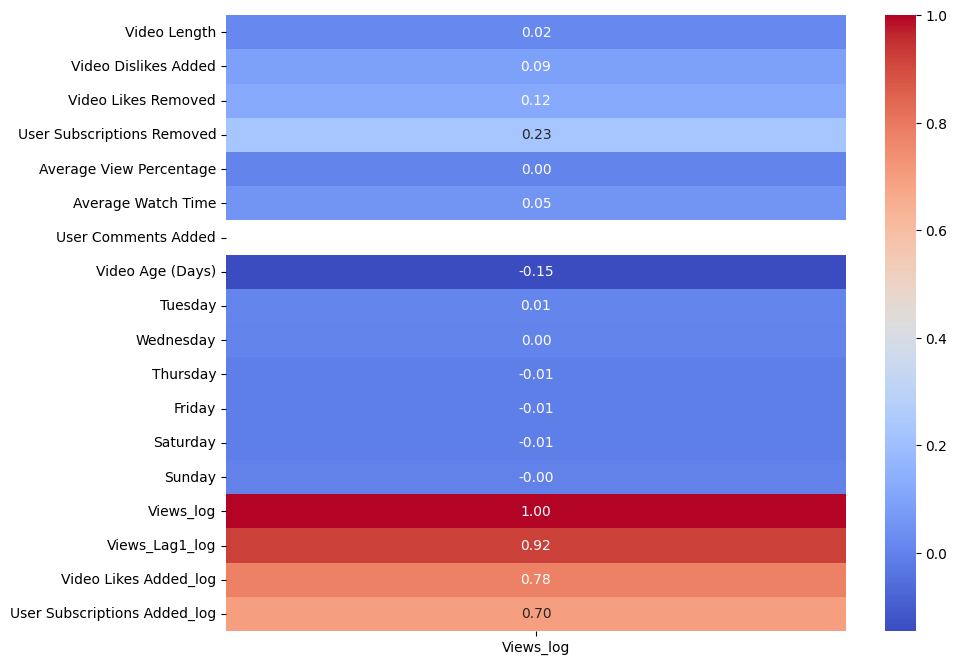

In [15]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix[['Views_log']], annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

### 1.5 Разделение данных на обучающую и тестовую выборки

In [16]:
df_sample = df.sample(n=10000, random_state=42)

features = ['Views_Lag1_log', 
            'Video Age (Days)', 'Video Length', 'Average View Percentage',
            'Video Likes Added_log', 'User Subscriptions Added_log',
            'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
target = 'Views_log'

X = df_sample[features]
y = df_sample[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер исходного набора: {df_views.shape}")
print(f"Размер подвыборки: {df_sample.shape}")
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер исходного набора: (111857, 15)
Размер подвыборки: (10000, 22)
Размер обучающей выборки: (8000, 12)
Размер тестовой выборки: (2000, 12)


## 4 Решение задачи регрессии

### Линейная регрессия

In [19]:
X_simple = sm.add_constant(X_train[['Views_Lag1_log']])
simple_model = sm.OLS(y_train, X_simple).fit()

simple_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Views_log   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                 4.324e+04
Date:                Fri, 15 May 2026   Prob (F-statistic):               0.00
Time:                        14:44:47   Log-Likelihood:                -3830.7
No. Observations:                8000   AIC:                             7665.
Df Residuals:                    7998   BIC:                             7679.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0004      0.004     -0.085      0.932      -0.009       0.008
Views_Lag1_log     0.9153      0.004    207.947      0.000       0.907       0.924
==============================================================================
Omnibus:                     6385.448   Durbin-Watson:                   2.016
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           581396.442
Skew:                           3.218   Prob(JB):                         0.00
Kurtosis:                      44.265   Cond. No.                         1.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
X_multi = sm.add_constant(X_train)
multi_model = sm.OLS(y_train, X_multi).fit()

multi_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Views_log   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                     4678.
Date:                Fri, 15 May 2026   Prob (F-statistic):               0.00
Time:                        14:44:50   Log-Likelihood:                -2928.1
No. Observations:                8000   AIC:                             5882.
Df Residuals:                    7987   BIC:                             5973.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            0.0336      0.010      3.343      0.001       0.014       0.053
Views_Lag1_log                   0.7280      0.006    125.421      0.000       0.717       0.739
Video Age (Days)                 0.0044      0.004      1.079      0.281      -0.004       0.012
Video Length                     0.0200      0.004      4.502      0.000       0.011       0.029
Average View Percentage          0.0062      0.005      1.371      0.171      -0.003       0.015
Video Likes Added_log            0.2174      0.007     31.724      0.000       0.204       0.231
User Subscriptions Added_log     0.0558      0.006      8.801      0.000       0.043       0.068
Tuesday                         -0.0518      0.015     -3.572      0.000      -0.080      -0.023
Wednesday                       -0.0479      0.014     -3.329      0.001      -0.076      -0.020
Thursday                        -0.0555      0.014     -3.843      0.000      -0.084      -0.027
Friday                          -0.0276      0.015     -1.894      0.058      -0.056       0.001
Saturday                        -0.0425      0.014     -2.951      0.003      -0.071      -0.014
Sunday                          -0.0013      0.014     -0.089      0.929      -0.030       0.027
==============================================================================
Omnibus:                     2658.509   Durbin-Watson:                   2.023
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            47797.905
Skew:                           1.126   Prob(JB):                         0.00
Kurtosis:                      14.761   Cond. No.                         11.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [21]:
multiple_results = pd.DataFrame({
    'Coefficient (Beta)': multi_model.params,
    't-stat': multi_model.tvalues,
    'p-value': multi_model.pvalues,
    'Lower CI': multi_model.conf_int()[0],
    'Upper CI': multi_model.conf_int()[1]
})

multiple_results['95% Conf. Interval'] = multiple_results.apply(
    lambda x: f"[{x['Lower CI']:.4f}, {x['Upper CI']:.4f}]", axis=1
)

multiple_results['Significant'] = multiple_results['p-value'] < 0.05

multiple_summary = multiple_results[['Coefficient (Beta)', 't-stat', 'p-value', '95% Conf. Interval', 'Significant']].round(4)
multiple_summary.sort_values(by='Coefficient (Beta)', ascending=False)
# multiple_summary.sort_values(by='p-value')
# multiple_summary.sort_values(by='t-stat', ascending=False)

,Coefficient (Beta),t-stat,p-value,95% Conf. Interval,Significant
Views_Lag1_log,0.7280,125.4212,0.0000,"[0.7166, 0.7394]",True
Video Likes Added_log,0.2174,31.7238,0.0000,"[0.2039, 0.2308]",True
User Subscriptions Added_log,0.0558,8.8013,0.0000,"[0.0434, 0.0683]",True
const,0.0336,3.3428,0.0008,"[0.0139, 0.0534]",True
Video Length,0.0200,4.5019,0.0000,"[0.0113, 0.0286]",True
Average View Percentage,0.0062,1.3706,0.1706,"[-0.0027, 0.0150]",False
Video Age (Days),0.0044,1.0790,0.2806,"[-0.0036, 0.0123]",False
Sunday,-0.0013,-0.0886,0.9294,"[-0.0297, 0.0271]",False
Friday,-0.0276,-1.8937,0.0583,"[-0.0561, 0.0010]",False
Saturday,-0.0425,-2.9515,0.0032,"[-0.0707, -0.0143]",True


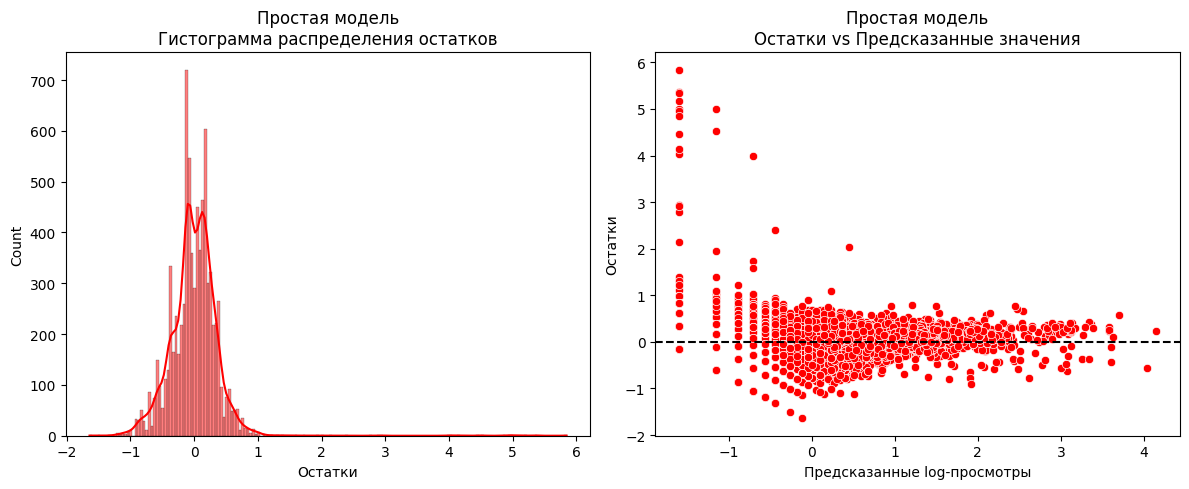

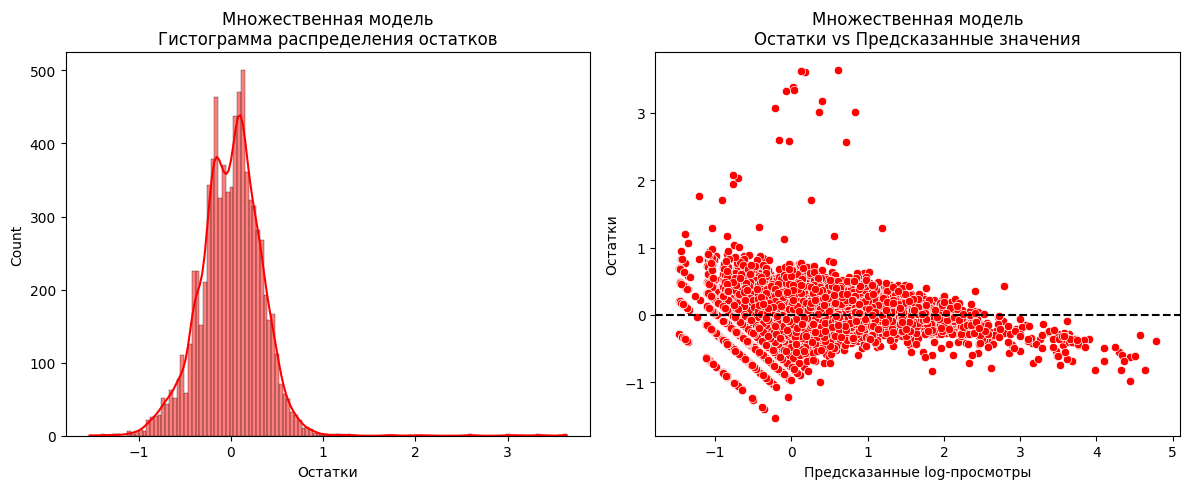

In [22]:
def analyze_residuals(model_name, model, X):
    y_pred = model.predict(sm.add_constant(X))
    residuals = y_train - y_pred

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    sns.histplot(data=residuals, kde=True, ax=ax[0], color=color)
    ax[0].set_title(model_name + '\nГистограмма распределения остатков')
    ax[0].set_xlabel('Остатки')

    sns.scatterplot(x=y_pred, y=residuals, ax=ax[1], color=color)
    ax[1].axhline(y=0, color='black', linestyle='--')
    ax[1].set_title(model_name + '\nОстатки vs Предсказанные значения')
    ax[1].set_xlabel('Предсказанные log-просмотры')
    ax[1].set_ylabel('Остатки')

    plt.tight_layout()
    plt.show()

analyze_residuals('Простая модель', simple_model, X_train[['Views_Lag1_log']])
analyze_residuals('Множественная модель', multi_model, X_train)

### Нелинейная регрессия

In [23]:
def create_nonlinear(X):
    X_nonlin = X.copy()
    X_nonlin['AvgViewPct_Squared'] = X['Average View Percentage']**2
    X_nonlin['Likes_x_Retention'] = X['Video Likes Added_log'] * X['Average View Percentage']
    return X_nonlin

X_train_nonlin = create_nonlinear(X_train)
X_test_nonlin = create_nonlinear(X_test)

X_nonlin_const = sm.add_constant(X_train_nonlin)
nonlin_model = sm.OLS(y_train, X_nonlin_const).fit()

nonlin_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Views_log   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.887
Method:                 Least Squares   F-statistic:                     4493.
Date:                Fri, 15 May 2026   Prob (F-statistic):               0.00
Time:                        14:44:58   Log-Likelihood:                -2525.8
No. Observations:                8000   AIC:                             5082.
Df Residuals:                    7985   BIC:                             5186.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            0.1118      0.010     11.245      0.000       0.092       0.131
Views_Lag1_log                   0.6711      0.006    114.473      0.000       0.660       0.683
Video Age (Days)                 0.0039      0.004      1.018      0.309      -0.004       0.012
Video Length                     0.0525      0.004     11.704      0.000       0.044       0.061
Average View Percentage          0.0781      0.006     13.648      0.000       0.067       0.089
Video Likes Added_log            0.2199      0.007     33.549      0.000       0.207       0.233
User Subscriptions Added_log     0.0668      0.006     11.024      0.000       0.055       0.079
Tuesday                         -0.0444      0.014     -3.220      0.001      -0.071      -0.017
Wednesday                       -0.0461      0.014     -3.370      0.001      -0.073      -0.019
Thursday                        -0.0489      0.014     -3.562      0.000      -0.076      -0.022
Friday                          -0.0223      0.014     -1.613      0.107      -0.049       0.005
Saturday                        -0.0374      0.014     -2.731      0.006      -0.064      -0.011
Sunday                           0.0016      0.014      0.117      0.907      -0.025       0.029
AvgViewPct_Squared              -0.0845      0.003    -28.978      0.000      -0.090      -0.079
Likes_x_Retention               -0.0201      0.007     -3.073      0.002      -0.033      -0.007
==============================================================================
Omnibus:                     2681.022   Durbin-Watson:                   2.026
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            45955.196
Skew:                           1.153   Prob(JB):                         0.00
Kurtosis:                      14.513   Cond. No.                         15.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [41]:
def get_metrics(model, X, add_const=True):
    if add_const == True: X = sm.add_constant(X, has_constant='add')
    
    y_pred_log = model.predict(X)
    
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)
    
    mae = mean_absolute_error(y_test_real, y_pred_real)
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    r2_test = r2_score(y_test, y_pred_log)
    
    n = len(y_test)
    p = X.shape[1] - 1
    adj_r2 = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)
    
    return [mae, mse, rmse, r2_test, adj_r2]

metrics_data = {
    'Простая линейная': get_metrics(simple_model, X_test['Views_Lag1_log']),
    'Множественная линейная': get_metrics(multi_model, X_test),
    'Нелинейная': get_metrics(nonlin_model, X_test_nonlin)
}

metrics_df = pd.DataFrame(metrics_data, index=['MAE', 'MSE', 'RMSE', 'R2', 'Adj. R2']).round(4)
metrics_df = metrics_df.T.reset_index().rename(columns={'index': 'Модель'})
metrics_df

,Модель,MAE,MSE,RMSE,R2,Adj. R2
0,Простая линейная,0.4698,6.0915,2.4681,0.8467,0.8466
1,Множественная линейная,0.6185,10.3460,3.2165,0.8737,0.8729
2,Нелинейная,0.5695,7.6145,2.7594,0.8875,0.8867


### Квантильная регрессия

In [ ]:
df_train = X_train.copy()
df_train['Views_log'] = y_train
new_names = {
    'Views_Lag1_log': 'Views_Lag1_log',
    'Video Likes Added_log': 'Likes_log',
    'User Subscriptions Added_log': 'Subs_log',
    'Video Length': 'Length',
    'Average View Percentage': 'AvgViewPct',
    'Video Age (Days)': 'Age'
}
df_train = df_train.rename(columns=new_names)

formula = "Views_log ~ Views_Lag1_log + Likes_log + Subs_log + Length + AvgViewPct"

quantiles = [0.25, 0.5, 0.75]
quantile_results = {}
for q in quantiles:
    res = smf.quantreg(formula, df_train).fit(q=q)
    quantile_results[q] = res.params

quantile_summary = pd.DataFrame(quantile_results)
quantile_summary.columns = [f'Q {q}' for q in quantiles]
quantile_summary.T.round(4)

,Intercept,Views_Lag1_log,Likes_log,Subs_log,Length,AvgViewPct
Q 0.25,-0.1916,0.8698,0.1252,0.0250,0.0186,0.0168
Q 0.5,-0.0135,0.8844,0.0895,0.0262,0.0169,0.0017
Q 0.75,0.2069,0.7817,0.1026,0.0416,0.0165,-0.0042


## 6 Применение ансамблевых моделей машинного обучения и регуляризации

In [48]:
ridge = Ridge(alpha=5.0)
ridge.fit(X_train, y_train)
ridge_metrics = get_metrics(ridge, X_test, add_const=False)
# y_pred_ridge = ridge.predict(X_test)

lasso = Lasso(alpha=0.05)
lasso.fit(X_train, y_train)
lasso_metrics = get_metrics(lasso, X_test, add_const=False)
# y_pred_lasso = lasso.predict(X_test)

In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'reg_alpha': [0.0, 1.0],      # L1-регуляризатор (аналог LASSO)
    'reg_lambda': [0.0, 10.0]     # L2-регуляризатор (аналог RIDGE)
}

grid_reg = GridSearchCV(
    lgb.LGBMRegressor(random_state=42, verbose=-1), param_grid, 
    cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_reg.fit(X_train, y_train)

print("Лучшие параметры LGBMRegressor:", grid_reg.best_params_)
lgb_model = grid_reg.best_estimator_
lgb_metrics = get_metrics(lgb_model, X_test, add_const=False)

Лучшие параметры LGBMRegressor: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'reg_alpha': 1.0, 'reg_lambda': 0.0}


In [57]:
regularization_results = pd.concat(
    [metrics_df,
    pd.DataFrame([{
        'Модель': 'RIDGE',
        'MAE': ridge_metrics[0],
        'MSE': ridge_metrics[1],
        'RMSE': ridge_metrics[2],
        'R2': ridge_metrics[3],
        'Adj. R2': ridge_metrics[4]
    }]),
    pd.DataFrame([{
        'Модель': 'LASSO',
        'MAE': lasso_metrics[0],
        'MSE': lasso_metrics[1],
        'RMSE': lasso_metrics[2],
        'R2': lasso_metrics[3],
        'Adj. R2': lasso_metrics[4]
    }]),
    pd.DataFrame([{
        'Модель': 'LGBMRegressor',
        'MAE': lgb_metrics[0],
        'MSE': lgb_metrics[1],
        'RMSE': lgb_metrics[2],
        'R2': lgb_metrics[3],
        'Adj. R2': lgb_metrics[4]
    }])],
    ignore_index=True
)

regularization_results

,Модель,MAE,MSE,RMSE,R2,Adj. R2
0,Простая линейная,0.469800,6.091500,2.468100,0.846700,0.846600
1,Множественная линейная,0.618500,10.346000,3.216500,0.873700,0.872900
2,Нелинейная,0.569500,7.614500,2.759400,0.887500,0.886700
3,RIDGE,0.618493,10.337315,3.215170,0.873669,0.872970
4,LASSO,0.461060,3.541128,1.881788,0.869910,0.869191
5,LGBMRegressor,0.318860,0.635440,0.797145,0.922233,0.921803


In [59]:
gain_importance = lgb_model.booster_.feature_importance(importance_type='gain')
importance_df = pd.DataFrame({'Feature': features, 'Gain': gain_importance}).sort_values(by='Gain', ascending=False)

importance_df

,Feature,Gain
0,Views_Lag1_log,34708.379499
4,Video Likes Added_log,1729.222730
3,Average View Percentage,956.503065
5,User Subscriptions Added_log,474.906859
2,Video Length,153.982567
1,Video Age (Days),86.200644
11,Sunday,4.799175
8,Thursday,1.680801
6,Tuesday,1.378748
10,Saturday,1.366870


In [ ]:
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer(X_train)

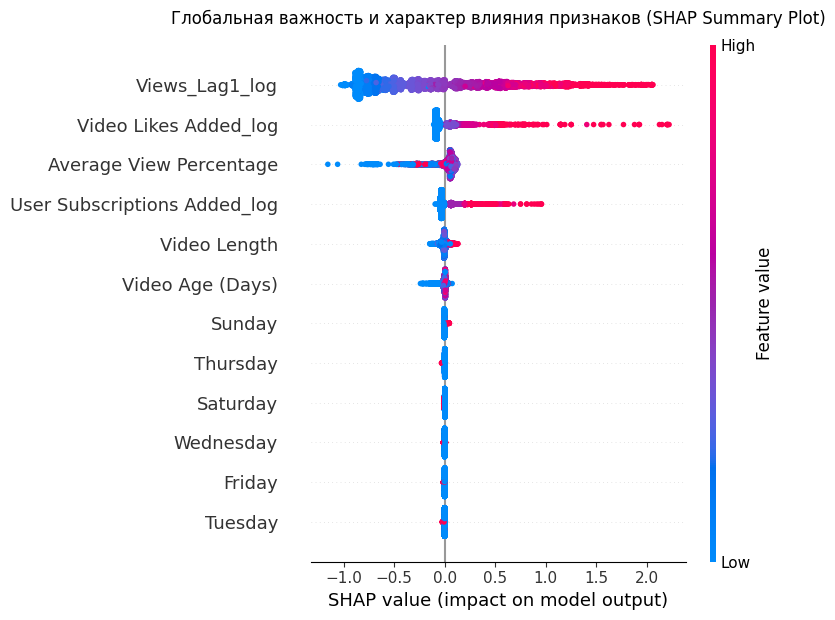

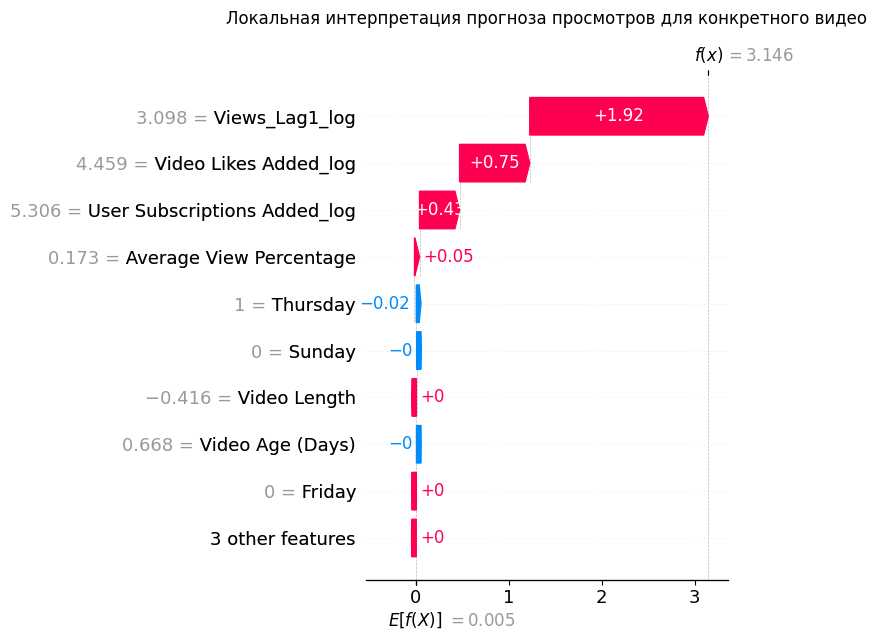

In [61]:
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_train, show=False)
plt.title('Глобальная важность и характер влияния признаков (SHAP Summary Plot)', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
shap.plots.waterfall(shap_values[0], show=False)
plt.title('Локальная интерпретация прогноза просмотров для конкретного видео', fontsize=12, pad=15)
plt.tight_layout()
plt.show()
